# Model Training

### Importing all the neccessary libraries

In [6]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.model_selection import RandomizedSearchCV

In [8]:
import warnings
warnings.filterwarnings('ignore')

In [10]:
import numpy as np
import pandas as pd

### Importing and reading the data

In [197]:
df = pd.read_csv("data.csv")

In [199]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [201]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [203]:
X = df.drop('math_score',axis = 1)
y = df['math_score']

In [205]:
X.shape,y.shape

((1000, 7), (1000,))

In [207]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

obj_cols = X.select_dtypes(include = 'O').columns
num_cols = X.select_dtypes(exclude = 'O').columns

ohe = OneHotEncoder(drop='first')
scaler = StandardScaler()

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state= 42)

transformer = ColumnTransformer(
    [
    ('OneHotEncoder',ohe,obj_cols),
    ('StandardScaler',scaler,num_cols)
    ],
    remainder='passthrough'
)

In [209]:
X_train = transformer.fit_transform(X_train)
X_test = transformer.transform(X_test)

In [211]:
X_train

array([[ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.86154402,  0.76641481],
       [ 0.        ,  0.        ,  1.        , ...,  0.        ,
         0.79091739,  0.69853042],
       [ 1.        ,  0.        ,  1.        , ...,  1.        ,
        -0.12722883, -0.52338868],
       ...,
       [ 0.        ,  0.        ,  1.        , ...,  1.        ,
        -0.55098863, -1.06646383],
       [ 1.        ,  0.        ,  1.        , ...,  0.        ,
        -1.53976148, -1.06646383],
       [ 0.        ,  0.        ,  0.        , ...,  1.        ,
         1.49718371,  1.37737436]])

## Creating Evaluation Metrics

In [214]:
def evaluation_metrics(true, predicted):
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(true, predicted)
    score = r2_score(true, predicted)
    return mse,mae,rmse,score

In [216]:
models = {
    'Linear Regression':LinearRegression(),
    'Ridge Regression':Ridge(),
    'Lasso Regression':Lasso(),
    'K Nearest Neighbour':KNeighborsRegressor(),
    'Support Vector Regression':SVR(),
    'Decision Tree':DecisionTreeRegressor(),
    'Random Forest':RandomForestRegressor(),
    'AdaBoost Regression':AdaBoostRegressor(),
    'XgBoost Regressor':XGBRegressor(),
    'CatBoost Regression':CatBoostRegressor()
}
model_list = []
r2_list = []

for name,model in models.items():
    model.fit(X_train,y_train) ## Train Model

    ## Make Prediction
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    #Evaluate Train and Test Models
    model_train_mse ,model_train_mae, model_train_rmse, model_train_score = evaluation_metrics(y_train,y_train_pred) ## Train
    
    model_test_mse ,model_test_mae, model_test_rmse, model_test_score = evaluation_metrics(y_test,y_test_pred) ## Test

    print(name)
    model_list.append(name)

    print('Model Performance for training set')
    print("-> Mean squared error : {:.4f}".format(model_train_mse))
    print("-> Mean absolute error : {:.4f}".format(model_train_mae))
    print("-> Root Mean squared error : {:.4f}".format(model_train_rmse))
    print("-> R2 Score : {:.4f}".format(model_train_score))

    print('-'*100)

    print('Model Performance for Testing set')
    print("-> Mean squared error : {:.4f}".format(model_test_mse))
    print("-> Mean absolute error : {:.4f}".format(model_test_mae))
    print("-> Root Mean squared error : {:.4f}".format(model_test_rmse))
    print("-> R2 Score : {:.4f}".format(model_test_score))
    r2_list.append(model_test_score)

    print('='*50)
    print('\n')

Linear Regression
Model Performance for training set
-> Mean squared error : 27.5447
-> Mean absolute error : 4.1985
-> Root Mean squared error : 5.2483
-> R2 Score : 0.8751
----------------------------------------------------------------------------------------------------
Model Performance for Testing set
-> Mean squared error : 30.8866
-> Mean absolute error : 4.4183
-> Root Mean squared error : 5.5576
-> R2 Score : 0.8759


Ridge Regression
Model Performance for training set
-> Mean squared error : 27.5503
-> Mean absolute error : 4.1979
-> Root Mean squared error : 5.2488
-> R2 Score : 0.8751
----------------------------------------------------------------------------------------------------
Model Performance for Testing set
-> Mean squared error : 30.9154
-> Mean absolute error : 4.4175
-> Root Mean squared error : 5.5602
-> R2 Score : 0.8757


Lasso Regression
Model Performance for training set
-> Mean squared error : 42.3089
-> Mean absolute error : 5.1532
-> Root Mean squared 

In [217]:
pd.DataFrame(list(zip(model_list,r2_list)),columns= ['model_name','r2_score']).sort_values(by = ['r2_score'],ascending=False)

,model_name,r2_score
0,Linear Regression,0.875863
1,Ridge Regression,0.875747
9,CatBoost Regression,0.850768
6,Random Forest,0.844278
7,AdaBoost Regression,0.836419
8,XgBoost Regressor,0.820321
2,Lasso Regression,0.810567
3,K Nearest Neighbour,0.776655
5,Decision Tree,0.744772
4,Support Vector Regression,0.714308


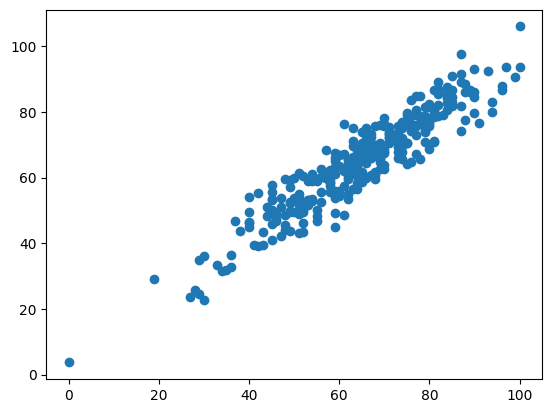

In [218]:
lin_model = LinearRegression()
lin_model.fit(X_train,y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test,y_pred)

import matplotlib.pyplot as plt
plt.scatter(y_test,y_pred)
plt.show()

<Axes: xlabel='math_score'>

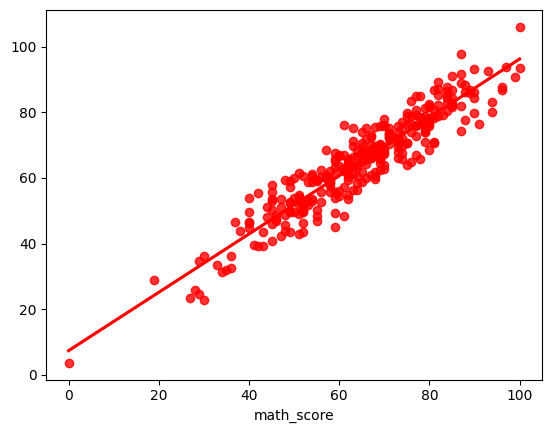

In [223]:
import seaborn as sns
sns.regplot(x= y_test,y= y_pred,ci = None, color='red')

In [225]:
pred_df = pd.DataFrame({'Actual Value': y_test,'Predicted Value': y_pred,'Difference': y_test-y_pred})

In [227]:
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.511652,14.488348
737,53,58.898180,-5.898180
740,80,76.938478,3.061522
660,74,76.965881,-2.965881
411,84,87.633152,-3.633152
...,...,...,...
468,77,72.854766,4.145234
935,70,62.606548,7.393452
428,65,58.650347,6.349653
7,40,44.841375,-4.841375
